1. Install Libraries

In [2]:
!pip install transformers scikit-learn pandas numpy matplotlib torch

2. Upload Dataset

In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [5]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])

print(df.head())
print(df.shape)

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
(72134, 4)


3. Data Cleaning

In [6]:
import re

df = df.dropna()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['content'] = (
    df['title'].astype(str) +
    " " +
    df['text'].astype(str)
).apply(clean_text)

4. Features and Labels

In [7]:
texts = df['content'].tolist()
labels = df['label'].tolist()

5. Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

6. TF-IDF Feature Extraction

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(train_texts).toarray()
X_test_tfidf = tfidf.transform(test_texts).toarray()

7. BERT Embedding Extraction

In [10]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

bert_model.eval()

def get_bert_embeddings(texts):

    embeddings = []

    for text in texts:

        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=256
        )

        with torch.no_grad():
            outputs = bert_model(**inputs)

        cls_embedding = outputs.last_hidden_state[:,0,:]

        embeddings.append(
            cls_embedding.squeeze().numpy()
        )

    return np.array(embeddings)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


8. Generate BERT Embeddings

In [11]:
import numpy as np

X_train_bert = get_bert_embeddings(train_texts[:2000])
X_test_bert = get_bert_embeddings(test_texts[:1000])


9. Feature Fusion

In [12]:
X_train = np.hstack(
    (
        X_train_tfidf[:len(X_train_bert)],
        X_train_bert
    )
)

X_test = np.hstack(
    (
        X_test_tfidf[:len(X_test_bert)],
        X_test_bert
    )
)

10. Labels

In [13]:
y_train = train_labels[:len(X_train)]
y_test = test_labels[:len(X_test)]

11. Random Forest Classifier

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=300, n_jobs=-1,
                       random_state=42)

12. Prediction

In [15]:
preds = model.predict(X_test)

13. Classification Report

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.90      0.84      0.86       481
           1       0.86      0.91      0.88       519

    accuracy                           0.87      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.88      0.87      0.87      1000



14. Performance Metrics

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds)
rec = recall_score(y_test, preds)
f1 = f1_score(y_test, preds)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.874
Precision: 0.8566243194192378
Recall   : 0.9094412331406551
F1 Score : 0.8822429906542056


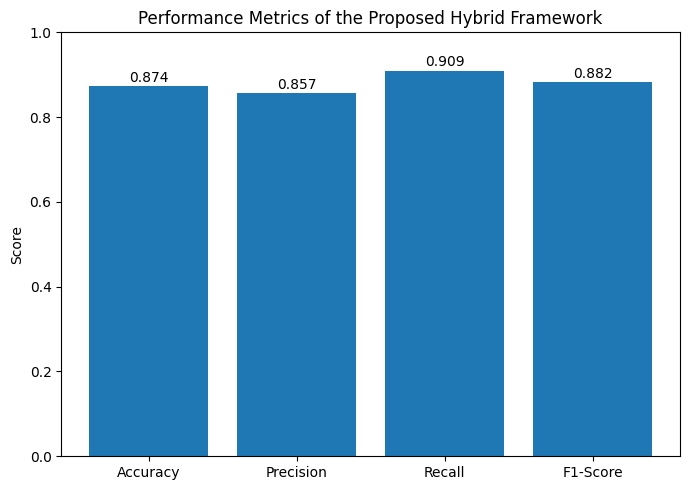

In [18]:
import matplotlib.pyplot as plt

metrics = [acc, prec, rec, f1]
names = ["Accuracy", "Precision", "Recall", "F1-Score"]

plt.figure(figsize=(7,5))

bars = plt.bar(names, metrics)

plt.ylabel("Score")
plt.ylim(0, 1.0)

plt.title("Performance Metrics of the Proposed Hybrid Framework")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

15. AUC Score

In [19]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, probs)

print("AUC:", auc)

AUC: 0.9467270738947038


16. Confusion Matrix

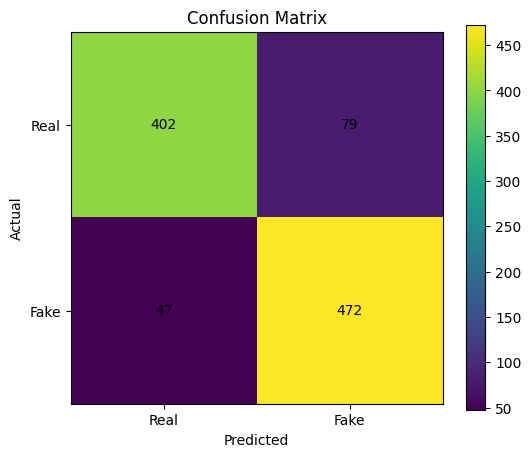

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Real","Fake"])
plt.yticks([0,1], ["Real","Fake"])

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(
            j,
            i,
            cm[i][j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

17. Performance Chart

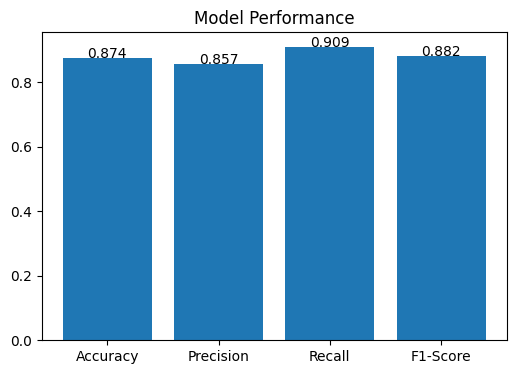

In [21]:
metrics = [acc, prec, rec, f1]

names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

plt.figure(figsize=(6,4))

plt.bar(names, metrics)

for i, v in enumerate(metrics):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.title("Model Performance")

plt.show()

18. Dataset Distribution

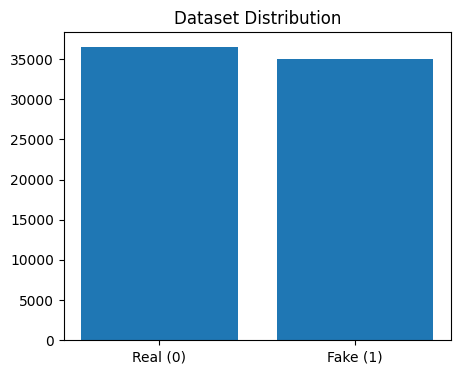

label
1    36509
0    35028
Name: count, dtype: int64


In [22]:
labels_count = df['label'].value_counts()

plt.figure(figsize=(5,4))

plt.bar(
    ["Real (0)", "Fake (1)"],
    labels_count
)

plt.title("Dataset Distribution")

plt.show()

print(labels_count)

In [23]:
print(df['label'].value_counts())

label
1    36509
0    35028
Name: count, dtype: int64


In [24]:
print(df.columns)

Index(['Unnamed: 0', 'title', 'text', 'label', 'content'], dtype='object')


In [25]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(57229, 10000)
(14308, 10000)


In [26]:
print(X_train_bert.shape)
print(X_test_bert.shape)

(2000, 768)
(1000, 768)


In [27]:
print(X_train.shape)
print(X_test.shape)

(2000, 10768)
(1000, 10768)


In [28]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.90      0.84      0.86       481
           1       0.86      0.91      0.88       519

    accuracy                           0.87      1000
   macro avg       0.88      0.87      0.87      1000
weighted avg       0.88      0.87      0.87      1000



In [29]:
print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

Accuracy : 0.874
Precision: 0.8566243194192378
Recall   : 0.9094412331406551
F1 Score : 0.8822429906542056


In [ ]:
print("AUC:", auc)

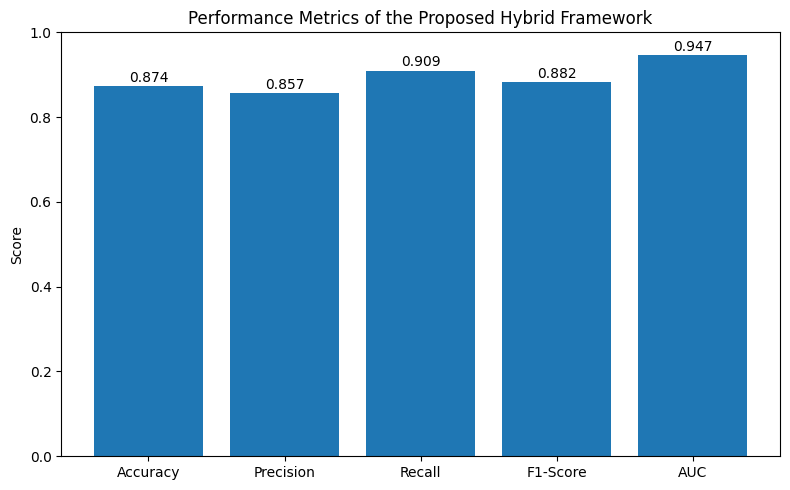

In [30]:
import matplotlib.pyplot as plt

metrics = [acc, prec, rec, f1, auc]
names = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]

plt.figure(figsize=(8,5))

bars = plt.bar(names, metrics)

plt.title("Performance Metrics of the Proposed Hybrid Framework")
plt.ylabel("Score")
plt.ylim(0, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

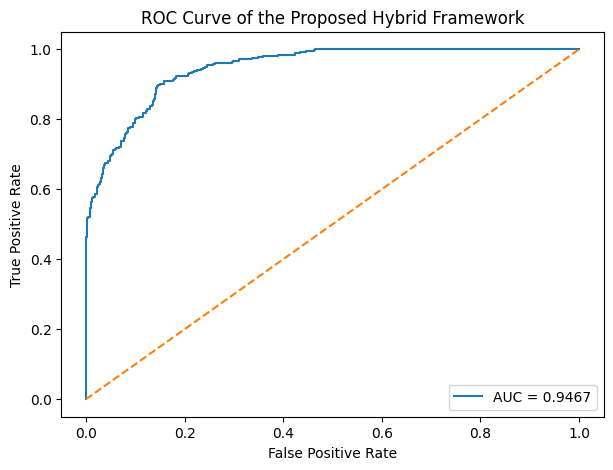

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of the Proposed Hybrid Framework")
plt.legend()

plt.show()

In [32]:
import joblib

joblib.dump(model, "fake_news_rf.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']